# ARRGO: Comparative Evaluation

This notebook evaluates ARRGO against several established optimization strategies using a common set of one-dimensional benchmark functions.

The purpose of this evaluation is to examine the empirical behavior of ARRGO relative to different search paradigms under a controlled and reproducible experimental protocol.

The comparison includes:

- ARRGO;
- Random Search;
- Hill Climbing;
- Genetic Algorithm;
- Simulated Annealing;
- SHGO (Simplicial Homology Global Optimization).

The selected methods represent different optimization paradigms, including:

- region-based adaptive search;
- random search;
- local search;
- evolutionary search;
- stochastic metaheuristic search;
- deterministic global optimization.

All methods are evaluated on the benchmark functions introduced in the experimental evaluation of ARRGO.

The comparison focuses on empirical behavior rather than theoretical superiority.

In particular, this notebook evaluates:

- best objective value found;
- objective-value error;
- location error where a unique optimum exists;
- number of objective-function evaluations;
- evaluation budget usage;
- convergence behavior;
- reproducibility and determinism where applicable.

The comparison is designed so that the methods operate under a common evaluation budget and are assessed using the same benchmark objectives and reference solutions.

Because the compared algorithms have different internal mechanisms and some methods are stochastic by design, reproducibility controls and method-specific considerations are explicitly documented.

The results of this notebook must therefore be interpreted as empirical evidence for the tested benchmarks and configurations, not as a universal proof that one optimization method is superior to all others.

## 2. Comparison Methodology

A fair comparison requires a common experimental protocol across all optimization methods.

The main principle is:

$$
\boxed{
\text{Same Problem}
+
\text{Same Evaluation Budget}
+
\text{Same Evaluation Metric}
}
$$

Each method is evaluated on the same objective functions and over the same bounded domains.

## 2.1 Common Benchmark Problems

All optimization methods use the benchmark functions defined in the ARRGO experimental evaluation.

For each benchmark:

- the objective function is identical for all methods;
- the optimization domain is identical for all methods;
- the reference optimum is identical for all methods;
- the objective is evaluated without exposing analytical derivatives to the optimizer.

This prevents differences in the objective definition or search domain from affecting the comparison.

## 2.2 Common Evaluation Budget

The primary resource used for comparison is the number of objective-function evaluations.

The common maximum budget is:

$$
N_{\max}=100.
$$

An objective-function evaluation is counted whenever a method explicitly evaluates:

$$
y=f(x).
$$

Algorithmic operations such as candidate generation, region splitting, population manipulation, or internal bookkeeping do not count as objective evaluations unless they require a new evaluation of \(f\).

This distinction is particularly important because different optimization methods perform different amounts of internal computation between objective evaluations.

## 2.3 Common Performance Measures

The primary performance measure is the best objective value found:

$$
f_{\mathrm{best}}
=
\max_{x_i\in D}f(x_i).
$$

For benchmarks with a known unique reference optimizer \(x^\ast\), location error is measured as:

$$
E_x
=
|x_{\mathrm{best}}-x^\ast|.
$$

Objective-value error is measured as:

$$
E_f
=
|f^\ast-f_{\mathrm{best}}|.
$$

For benchmarks with multiple global maximizers, location error is interpreted relative to the set of valid optimal locations rather than a single reference point.

## 2.4 Convergence Comparison

When possible, the evolution of the best objective value is recorded as a function of the number of objective evaluations:

$$
f_{\mathrm{best}}^{(1)},
f_{\mathrm{best}}^{(2)},
\ldots,
f_{\mathrm{best}}^{(N)}.
$$

This allows methods with different internal iteration structures to be compared using a common horizontal axis.

The comparison therefore emphasizes information acquired from the objective function rather than the number of algorithm-specific iterations.

## 2.5 Stochastic Methods

Some comparison methods are stochastic.

For these methods, a fixed random seed is used when the implementation permits deterministic reproducibility.

The use of a fixed seed provides a reproducible experimental configuration, but it does not make a stochastic algorithm deterministic in its mathematical nature.

Therefore, results from stochastic methods are interpreted as observations under the specified random configuration.

ARRGO itself remains deterministic under the experimental configuration used in this project.

## 2.6 Method-Specific Parameters

Each algorithm may require parameters that have no direct equivalent in ARRGO.

Such parameters are selected using reasonable standard settings or explicitly documented configurations.

The comparison does not attempt to tune every algorithm exhaustively.

Therefore, the results represent the behavior of the tested configurations rather than the absolute best possible performance of each method.

## 2.7 Interpretation Principle

The comparison is descriptive and empirical.

The experiment can establish statements such as:

> Method A achieved a better objective value than Method B on the tested benchmark under the specified evaluation budget.

It cannot establish the universal statement:

> Method A is globally superior to Method B for all optimization problems.

Therefore:

$$
\boxed{
\text{Experimental Comparison}
\neq
\text{Universal Superiority Proof}.
}
$$

## 3. Benchmark Functions

The comparative evaluation uses the same one-dimensional benchmark suite introduced in the ARRGO experimental evaluation.

Using the same benchmark definitions ensures that the comparison is performed under identical objective functions and domains.

The benchmark suite contains five functions representing different optimization characteristics.

### 3.1 Quadratic Unimodal Function

$$
f_1(x)=-(x-2)^2+5,
\qquad
x\in[-5,5].
$$

The global maximum is:

$$
x^\ast=2,
\qquad
f^\ast=5.
$$

This function represents a smooth unimodal optimization problem with a unique interior optimum.

### 3.2 Asymmetric Smooth Function

$$
f_2(x)
=
-(x-0.8)^2
-
0.15(x-0.8)^3
+
4,
\qquad
x\in[-4,4].
$$

The reference optimum is approximately:

$$
x^\ast\approx0.8,
\qquad
f^\ast\approx4.
$$

This benchmark introduces asymmetry while preserving a smooth objective landscape.

### 3.3 Multimodal Trigonometric Function

$$
f_3(x)
=
\sin(3x)+0.3\sin(9x),
\qquad
x\in[-\pi,\pi].
$$

The reference global optimum is approximately:

$$
x^\ast\approx0.7761349460,
$$

with:

$$
f^\ast\approx0.9202119992.
$$

This benchmark evaluates the ability of optimization methods to handle multiple local maxima.

### 3.4 Narrow Peak Function

$$
f_4(x)
=
\exp\left(
-\frac{(x-1.5)^2}{0.08}
\right),
\qquad
x\in[-4,4].
$$

The global maximum is approximately:

$$
x^\ast=1.5,
\qquad
f^\ast=1.
$$

The narrow peak creates a difficult information-acquisition problem because high objective values are concentrated in a small region of the search domain.

### 3.5 Flat Peak Function

$$
f_5(x)
=
-\left(\max(|x-1|-1,0)\right)^2,
\qquad
x\in[-4,4].
$$

Every point in:

$$
[0,2]
$$

is a global maximizer, with:

$$
f^\ast=0.
$$

This benchmark therefore has a non-unique global optimum.

For this function, a location is considered optimal when:

$$
x_{\mathrm{best}}\in[0,2].
$$

A single reference location is therefore not used to judge location accuracy.

## 3.6 Benchmark Diversity

The benchmark suite intentionally contains different objective structures:

| Benchmark | Main characteristic |
|---|---|
| Quadratic | Smooth unimodal landscape |
| Asymmetric Smooth | Asymmetric smooth landscape |
| Multimodal Trigonometric | Multiple local maxima |
| Narrow Peak | Highly localized optimum |
| Flat Peak | Non-unique global optimum |

The same five benchmark problems are supplied to every comparison method.

This allows the experiment to examine whether different search strategies behave differently under changes in objective structure rather than under changes in the problem definition.

## 4. Reference Solutions

To evaluate optimization accuracy, each benchmark is associated with a reference global optimum.

The reference solutions are treated as external evaluation targets and are not supplied to any optimization method during execution.

For each benchmark, the reference data contains:

- the reference optimizer \(x^\ast\);
- the reference objective value \(f^\ast\);
- whether the global optimum is unique;
- the valid optimal-location set when the optimum is non-unique.

The reference values are:

| Benchmark | Reference \(x^\ast\) | Reference \(f^\ast\) | Optimum Type |
|---|---:|---:|---|
| Quadratic Unimodal | \(2\) | \(5\) | Unique |
| Asymmetric Smooth | \(\approx0.8\) | \(\approx4\) | Unique |
| Multimodal Trigonometric | \(\approx0.7761349460\) | \(\approx0.9202119992\) | Unique |
| Narrow Peak | \(\approx1.5\) | \(1\) | Unique |
| Flat Peak | \([0,2]\) | \(0\) | Non-unique |

The reference values are used only after an optimization method has produced its result.

No method receives the reference optimizer or reference objective value as input.

For benchmarks with a unique optimizer, the location error is:

$$
E_x
=
|x_{\mathrm{best}}-x^\ast|.
$$

The objective-value error is:

$$
E_f
=
|f^\ast-f_{\mathrm{best}}|.
$$

For the flat-peak benchmark, the location is considered valid when:

$$
x_{\mathrm{best}}\in[0,2].
$$

Therefore, a numerical distance from one arbitrarily selected reference point is not used as the primary location metric for this benchmark.

The reference solutions provide a common evaluation standard across all optimization methods.

## 4. Random Benchmark Generation Strategy

In addition to the fixed benchmark functions used in the previous experimental evaluation, the comparative study uses a collection of randomly generated one-dimensional objective functions.

The purpose of random benchmark generation is to reduce the dependence of the comparison on a small number of manually selected functions.

A total of:

$$
N_{\mathrm{functions}}=300
$$

random benchmark functions will be generated.

Each generated function remains a deterministic, bounded, continuous one-dimensional optimization problem.

## 4.1 Common Domain

All generated functions are defined over the normalized domain:

$$
\Omega=[-5,5].
$$

Using a common domain simplifies comparison between optimization methods while still allowing substantial variation in the objective landscape.

## 4.2 Random Function Family

Each random objective is constructed as a finite mixture of smooth localized components:

$$
f(x)
=
\sum_{k=1}^{K}
a_k
\exp
\left(
-\frac{(x-\mu_k)^2}{2\sigma_k^2}
\right)
+
b_1x+b_0,
$$

where:

- \(K\) is the randomly selected number of components;
- \(a_k\) controls the amplitude of component \(k\);
- \(\mu_k\) controls its location;
- \(\sigma_k\) controls its width;
- \(b_1\) controls a small global trend;
- \(b_0\) controls the objective offset.

The parameters are generated using a fixed master random seed so that the complete benchmark suite can be reproduced exactly.

## 4.3 Landscape Diversity

The random generator is designed to produce different objective landscapes, including:

- approximately unimodal functions;
- multimodal functions;
- asymmetric landscapes;
- functions with narrow peaks;
- functions with broad peaks;
- functions with multiple competing maxima;
- functions with optima near domain boundaries;
- functions with relatively flat regions.

The number, location, amplitude, and width of the components vary between generated functions.

Consequently, different random functions can require substantially different search behavior.

## 4.4 Reference Solutions

Because the generated functions do not have a single predefined analytical optimizer, a reference solution is computed independently for each generated objective.

The reference procedure uses a substantially finer evaluation resolution than the optimization methods used in the comparison.

The reference optimizer is therefore treated as an evaluation target rather than as another competing optimization method.

The reference value is denoted by:

$$
x_i^\ast
$$

and:

$$
f_i^\ast=f_i(x_i^\ast),
$$

for random benchmark \(i\).

The reference computation is performed independently from the evaluation budget assigned to the compared optimization methods.

## 4.5 Separation of Reference Computation and Optimization Budget

Reference evaluations are not counted toward the optimization budget of any compared method.

The common optimization budget remains:

$$
N_{\max}=100.
$$

Therefore, every optimization method receives the same maximum number of objective-function evaluations for every generated benchmark.

The reference computation exists only to provide a common accuracy target.

## 4.6 Reproducibility

The complete random benchmark suite is generated from a fixed master seed.

Therefore:

$$
\boxed{
\text{Same Seed}
\Rightarrow
\text{Same Benchmark Suite}.
}
$$

The generated functions, their parameters, and their reference solutions can consequently be reproduced in future executions.

## 4.7 Purpose of the Random Benchmark Study

The 300-function experiment is intended to answer a broader empirical question:

> How does ARRGO behave relative to alternative optimization strategies across a diverse collection of deterministic objective landscapes?

The results are interpreted statistically across the generated benchmark suite rather than from a single function.

The random benchmark study therefore complements the fixed benchmark experiments from Notebook 06.

In [1]:
import numpy as np
import pandas as pd


RANDOM_BENCHMARK_SEED = 20260915
RANDOM_BENCHMARK_COUNT = 300

RANDOM_DOMAIN_LOWER = -5.0
RANDOM_DOMAIN_UPPER = 5.0


def generate_random_function_parameters(
    rng: np.random.Generator,
) -> dict:
    component_count = int(rng.integers(2, 7))

    amplitudes = rng.uniform(0.5, 2.0, size=component_count)
    centers = rng.uniform(
        RANDOM_DOMAIN_LOWER,
        RANDOM_DOMAIN_UPPER,
        size=component_count,
    )
    widths = rng.uniform(0.15, 1.5, size=component_count)

    trend = rng.uniform(-0.15, 0.15)
    offset = rng.uniform(-1.0, 1.0)

    return {
        "component_count": component_count,
        "amplitudes": amplitudes,
        "centers": centers,
        "widths": widths,
        "trend": trend,
        "offset": offset,
    }


def build_random_objective(parameters: dict):
    amplitudes = np.asarray(parameters["amplitudes"], dtype=float)
    centers = np.asarray(parameters["centers"], dtype=float)
    widths = np.asarray(parameters["widths"], dtype=float)
    trend = float(parameters["trend"])
    offset = float(parameters["offset"])

    def objective(x):
        x_array = np.asarray(x, dtype=float)

        value = np.zeros_like(x_array, dtype=float)

        for amplitude, center, width in zip(
            amplitudes,
            centers,
            widths,
        ):
            value += amplitude * np.exp(
                -((x_array - center) ** 2)
                / (2.0 * width**2)
            )

        value += trend * x_array
        value += offset

        if np.ndim(x) == 0:
            return float(value)

        return value

    return objective


def generate_random_benchmarks(
    count: int = RANDOM_BENCHMARK_COUNT,
    seed: int = RANDOM_BENCHMARK_SEED,
) -> list[dict]:
    rng = np.random.default_rng(seed)

    benchmarks = []

    for benchmark_id in range(1, count + 1):
        parameters = generate_random_function_parameters(rng)
        objective = build_random_objective(parameters)

        benchmarks.append(
            {
                "id": benchmark_id,
                "objective": objective,
                "parameters": parameters,
                "lower_bound": RANDOM_DOMAIN_LOWER,
                "upper_bound": RANDOM_DOMAIN_UPPER,
            }
        )

    return benchmarks


random_benchmarks = generate_random_benchmarks()

assert len(random_benchmarks) == RANDOM_BENCHMARK_COUNT

print(
    f"Generated {len(random_benchmarks)} deterministic random benchmark functions."
)

Generated 300 deterministic random benchmark functions.


In [2]:
from scipy.optimize import minimize_scalar


REFERENCE_GRID_SIZE = 20_001
REFERENCE_TOP_CANDIDATES = 10


def compute_reference_solution(
    objective,
    lower_bound: float,
    upper_bound: float,
    grid_size: int = REFERENCE_GRID_SIZE,
    top_candidates: int = REFERENCE_TOP_CANDIDATES,
) -> dict:
    grid = np.linspace(
        lower_bound,
        upper_bound,
        grid_size,
    )

    values = np.asarray(objective(grid), dtype=float)

    if not np.all(np.isfinite(values)):
        raise ValueError("Reference evaluation produced non-finite values.")

    candidate_count = min(top_candidates, grid_size)

    top_indices = np.argpartition(
        values,
        -candidate_count,
    )[-candidate_count:]

    top_indices = top_indices[
        np.argsort(values[top_indices])[::-1]
    ]

    best_x = float(grid[top_indices[0]])
    best_value = float(values[top_indices[0]])

    grid_step = (upper_bound - lower_bound) / (grid_size - 1)

    for index in top_indices:
        left_index = max(0, int(index) - 1)
        right_index = min(grid_size - 1, int(index) + 1)

        left = float(grid[left_index])
        right = float(grid[right_index])

        if right <= left:
            continue

        result = minimize_scalar(
            lambda x: -float(objective(x)),
            bounds=(left, right),
            method="bounded",
            options={"xatol": grid_step * 1e-3},
        )

        if result.success and np.isfinite(result.fun):
            candidate_x = float(result.x)
            candidate_value = float(-result.fun)

            if candidate_value > best_value:
                best_x = candidate_x
                best_value = candidate_value

    return {
        "reference_x": best_x,
        "reference_value": best_value,
    }


reference_results = []

for benchmark in random_benchmarks:
    reference = compute_reference_solution(
        objective=benchmark["objective"],
        lower_bound=benchmark["lower_bound"],
        upper_bound=benchmark["upper_bound"],
    )

    reference_results.append(
        {
            "id": benchmark["id"],
            **reference,
        }
    )


reference_df = pd.DataFrame(reference_results)

assert len(reference_df) == RANDOM_BENCHMARK_COUNT
assert reference_df["reference_x"].between(
    RANDOM_DOMAIN_LOWER,
    RANDOM_DOMAIN_UPPER,
).all()

assert np.isfinite(reference_df["reference_value"]).all()

print(
    f"Computed reference solutions for {len(reference_df)} benchmark functions."
)

reference_df.head()

Computed reference solutions for 300 benchmark functions.


,id,reference_x,reference_value
0,1,1.297821,3.186781
1,2,-0.667731,3.358609
2,3,-4.177610,1.633090
3,4,2.887881,1.186046
4,5,1.317346,4.006746


In [3]:
class EvaluationBudgetExceeded(Exception):
    """Raised when an optimization method reaches its evaluation budget."""
    pass


class EvaluationTracker:
    def __init__(self, objective, max_evaluations: int = 100):
        if max_evaluations <= 0:
            raise ValueError("max_evaluations must be positive.")

        self.objective = objective
        self.max_evaluations = max_evaluations

        self.evaluation_count = 0
        self.best_x = None
        self.best_value = None

        self.history = []

    def evaluate(self, x: float) -> float:
        if self.evaluation_count >= self.max_evaluations:
            raise EvaluationBudgetExceeded(
                "The maximum number of function evaluations has been reached."
            )

        x = float(x)
        value = float(self.objective(x))

        if not np.isfinite(value):
            raise ValueError("Objective returned a non-finite value.")

        self.evaluation_count += 1

        self.history.append(
            {
                "evaluation": self.evaluation_count,
                "x": x,
                "value": value,
            }
        )

        if (
            self.best_value is None
            or value > self.best_value
        ):
            self.best_x = x
            self.best_value = value

        return value

    def result(self) -> dict:
        return {
            "best_x": self.best_x,
            "best_value": self.best_value,
            "evaluations": self.evaluation_count,
            "history": self.history.copy(),
        }


def create_tracker(objective, max_evaluations: int = 100):
    return EvaluationTracker(
        objective=objective,
        max_evaluations=max_evaluations,
    )


# Basic validation
test_tracker = create_tracker(
    objective=lambda x: -(x - 2.0) ** 2 + 5.0,
    max_evaluations=3,
)

test_tracker.evaluate(0.0)
test_tracker.evaluate(2.0)
test_tracker.evaluate(4.0)

assert test_tracker.evaluation_count == 3
assert test_tracker.best_x == 2.0
assert test_tracker.best_value == 5.0

try:
    test_tracker.evaluate(1.0)
    raise AssertionError("Evaluation budget was not enforced.")
except EvaluationBudgetExceeded:
    pass

print("Evaluation budget tracker tests passed.")

Evaluation budget tracker tests passed.


In [14]:
from arrgo import (
    ARRGOConfig,
    run_arrgo,
)


COMPARISON_MAX_EVALUATIONS = 100
COMPARISON_CONTRACTION_FACTOR = 0.75


def run_arrgo_comparison(
    objective,
    lower_bound: float,
    upper_bound: float,
    max_evaluations: int = COMPARISON_MAX_EVALUATIONS,
):
    config = ARRGOConfig(
        lower_bound=lower_bound,
        upper_bound=upper_bound,
        max_evaluations=max_evaluations,
        contraction_factor=COMPARISON_CONTRACTION_FACTOR,
    )

    result = run_arrgo(
        objective=objective,
        config=config,
    )

    return {
        "best_x": float(result.best_x),
        "best_value": float(result.best_value),
        "evaluations": int(result.evaluation_count),
        "history": result.state.evaluation_history,
        "termination": result.termination_reason.value,
    }


# Basic validation
arrgo_test = run_arrgo_comparison(
    objective=lambda x: -(x - 2.0) ** 2 + 5.0,
    lower_bound=-5.0,
    upper_bound=5.0,
    max_evaluations=100,
)

assert arrgo_test["evaluations"] <= 100
assert -5.0 <= arrgo_test["best_x"] <= 5.0
assert np.isfinite(arrgo_test["best_value"])

print("ARRGO comparison wrapper validation passed.")
print(f"ARRGO evaluations: {arrgo_test['evaluations']}")
print(f"ARRGO best x: {arrgo_test['best_x']:.6f}")
print(f"ARRGO best value: {arrgo_test['best_value']:.6f}")
print(f"ARRGO termination: {arrgo_test['termination']}")

ARRGO comparison wrapper validation passed.
ARRGO evaluations: 100
ARRGO best x: 2.007779
ARRGO best value: 4.999939
ARRGO termination: budget_exhausted


In [5]:
def run_random_search(
    objective,
    lower_bound: float,
    upper_bound: float,
    max_evaluations: int = COMPARISON_MAX_EVALUATIONS,
    seed: int = 0,
) -> dict:
    rng = np.random.default_rng(seed)

    tracker = create_tracker(
        objective=objective,
        max_evaluations=max_evaluations,
    )

    while tracker.evaluation_count < max_evaluations:
        x = rng.uniform(
            lower_bound,
            upper_bound,
        )

        tracker.evaluate(x)

    result = tracker.result()

    return {
        "best_x": result["best_x"],
        "best_value": result["best_value"],
        "evaluations": result["evaluations"],
        "history": result["history"],
        "termination": "budget_exhausted",
    }


# Basic validation
random_search_test = run_random_search(
    objective=lambda x: -(x - 2.0) ** 2 + 5.0,
    lower_bound=-5.0,
    upper_bound=5.0,
    max_evaluations=100,
    seed=42,
)

assert random_search_test["evaluations"] == 100
assert -5.0 <= random_search_test["best_x"] <= 5.0
assert np.isfinite(random_search_test["best_value"])

print("Random Search validation passed.")

Random Search validation passed.


In [6]:
def run_hill_climbing(
    objective,
    lower_bound: float,
    upper_bound: float,
    max_evaluations: int = COMPARISON_MAX_EVALUATIONS,
    seed: int = 0,
    initial_step: float = 0.5,
    step_decay: float = 0.5,
    min_step: float = 1e-4,
) -> dict:
    rng = np.random.default_rng(seed)

    tracker = create_tracker(
        objective=objective,
        max_evaluations=max_evaluations,
    )

    current_x = float(
        rng.uniform(
            lower_bound,
            upper_bound,
        )
    )

    current_value = tracker.evaluate(current_x)

    step = float(initial_step)

    while tracker.evaluation_count < max_evaluations:
        candidates = [
            max(lower_bound, current_x - step),
            min(upper_bound, current_x + step),
        ]

        improved = False

        for candidate_x in candidates:
            if tracker.evaluation_count >= max_evaluations:
                break

            candidate_value = tracker.evaluate(candidate_x)

            if candidate_value > current_value:
                current_x = candidate_x
                current_value = candidate_value
                improved = True

        if not improved:
            step *= step_decay

            if step < min_step:
                step = initial_step

    result = tracker.result()

    return {
        "best_x": result["best_x"],
        "best_value": result["best_value"],
        "evaluations": result["evaluations"],
        "history": result["history"],
        "termination": "budget_exhausted",
    }


# Basic validation
hill_climbing_test = run_hill_climbing(
    objective=lambda x: -(x - 2.0) ** 2 + 5.0,
    lower_bound=-5.0,
    upper_bound=5.0,
    max_evaluations=100,
    seed=42,
)

assert hill_climbing_test["evaluations"] == 100
assert -5.0 <= hill_climbing_test["best_x"] <= 5.0
assert np.isfinite(hill_climbing_test["best_value"])

print("Hill Climbing validation passed.")

Hill Climbing validation passed.


In [8]:
def run_genetic_algorithm(
    objective,
    lower_bound: float,
    upper_bound: float,
    max_evaluations: int = COMPARISON_MAX_EVALUATIONS,
    seed: int = 0,
    population_size: int = 10,
    mutation_rate: float = 0.2,
    mutation_scale: float = 0.1,
    tournament_size: int = 3,
) -> dict:
    if population_size <= 0:
        raise ValueError("population_size must be positive.")

    if tournament_size <= 0:
        raise ValueError("tournament_size must be positive.")

    rng = np.random.default_rng(seed)

    tracker = create_tracker(
        objective=objective,
        max_evaluations=max_evaluations,
    )

    population_size = min(population_size, max_evaluations)

    population = rng.uniform(
        lower_bound,
        upper_bound,
        size=population_size,
    )

    fitness = []

    for x in population:
        fitness.append(tracker.evaluate(float(x)))

    fitness = np.asarray(fitness, dtype=float)

    while tracker.evaluation_count < max_evaluations:
        new_population = []

        while (
            len(new_population) < population_size
            and tracker.evaluation_count + len(new_population)
            < max_evaluations
        ):
            tournament_count = min(
                tournament_size,
                population_size,
            )

            tournament_indices = rng.choice(
                population_size,
                size=tournament_count,
                replace=False,
            )

            parent_index = tournament_indices[
                np.argmax(fitness[tournament_indices])
            ]

            parent = population[parent_index]

            if rng.random() < mutation_rate:
                mutation = rng.normal(
                    loc=0.0,
                    scale=mutation_scale * (
                        upper_bound - lower_bound
                    ),
                )
                child = parent + mutation
            else:
                child = parent

            child = float(
                np.clip(
                    child,
                    lower_bound,
                    upper_bound,
                )
            )

            new_population.append(child)

        if not new_population:
            break

        offspring_fitness = np.asarray(
            [
                tracker.evaluate(x)
                for x in new_population
            ],
            dtype=float,
        )

        combined_population = np.concatenate(
            [population, np.asarray(new_population)]
        )

        combined_fitness = np.concatenate(
            [fitness, offspring_fitness]
        )

        survivor_count = min(
            population_size,
            len(combined_population),
        )

        survivor_indices = np.argsort(
            combined_fitness
        )[-survivor_count:][::-1]

        population = combined_population[survivor_indices]
        fitness = combined_fitness[survivor_indices]

    result = tracker.result()

    return {
        "best_x": result["best_x"],
        "best_value": result["best_value"],
        "evaluations": result["evaluations"],
        "history": result["history"],
        "termination": "budget_exhausted",
    }


# Basic validation
genetic_algorithm_test = run_genetic_algorithm(
    objective=lambda x: -(x - 2.0) ** 2 + 5.0,
    lower_bound=-5.0,
    upper_bound=5.0,
    max_evaluations=100,
    seed=42,
)

assert genetic_algorithm_test["evaluations"] == 100
assert -5.0 <= genetic_algorithm_test["best_x"] <= 5.0
assert np.isfinite(genetic_algorithm_test["best_value"])

print("Genetic Algorithm validation passed.")

Genetic Algorithm validation passed.


In [9]:
def run_simulated_annealing(
    objective,
    lower_bound: float,
    upper_bound: float,
    max_evaluations: int = COMPARISON_MAX_EVALUATIONS,
    seed: int = 0,
    initial_temperature: float = 1.0,
    final_temperature: float = 1e-3,
    step_scale: float = 0.1,
) -> dict:
    if initial_temperature <= 0:
        raise ValueError("initial_temperature must be positive.")

    if final_temperature <= 0:
        raise ValueError("final_temperature must be positive.")

    if final_temperature >= initial_temperature:
        raise ValueError(
            "final_temperature must be smaller than initial_temperature."
        )

    rng = np.random.default_rng(seed)

    tracker = create_tracker(
        objective=objective,
        max_evaluations=max_evaluations,
    )

    current_x = float(
        rng.uniform(
            lower_bound,
            upper_bound,
        )
    )

    current_value = tracker.evaluate(current_x)

    total_budget = max_evaluations - 1

    for iteration in range(total_budget):
        if tracker.evaluation_count >= max_evaluations:
            break

        progress = (
            iteration / max(total_budget - 1, 1)
        )

        temperature = (
            initial_temperature
            * (
                final_temperature
                / initial_temperature
            ) ** progress
        )

        step = (
            step_scale
            * (upper_bound - lower_bound)
        )

        candidate_x = current_x + rng.normal(
            loc=0.0,
            scale=step,
        )

        candidate_x = float(
            np.clip(
                candidate_x,
                lower_bound,
                upper_bound,
            )
        )

        candidate_value = tracker.evaluate(candidate_x)

        delta = candidate_value - current_value

        if delta >= 0:
            accept = True
        else:
            acceptance_probability = np.exp(
                delta / max(temperature, 1e-12)
            )
            accept = rng.random() < acceptance_probability

        if accept:
            current_x = candidate_x
            current_value = candidate_value

    result = tracker.result()

    return {
        "best_x": result["best_x"],
        "best_value": result["best_value"],
        "evaluations": result["evaluations"],
        "history": result["history"],
        "termination": "budget_exhausted",
    }


# Basic validation
simulated_annealing_test = run_simulated_annealing(
    objective=lambda x: -(x - 2.0) ** 2 + 5.0,
    lower_bound=-5.0,
    upper_bound=5.0,
    max_evaluations=100,
    seed=42,
)

assert simulated_annealing_test["evaluations"] == 100
assert -5.0 <= simulated_annealing_test["best_x"] <= 5.0
assert np.isfinite(simulated_annealing_test["best_value"])

print("Simulated Annealing validation passed.")

Simulated Annealing validation passed.


In [11]:
from scipy.optimize import shgo


def run_shgo(
    objective,
    lower_bound: float,
    upper_bound: float,
    max_evaluations: int = COMPARISON_MAX_EVALUATIONS,
    seed: int = 0,
) -> dict:
    # SHGO is deterministic for a fixed configuration.
    _ = seed

    evaluation_history = []
    best_x = None
    best_value = None

    def tracked_objective(x):
        nonlocal best_x, best_value

        if len(evaluation_history) >= max_evaluations:
            raise EvaluationBudgetExceeded(
                "SHGO reached the maximum evaluation budget."
            )

        x_value = float(
            np.asarray(x).reshape(-1)[0]
        )

        value = float(objective(x_value))

        if not np.isfinite(value):
            raise ValueError(
                "Objective returned a non-finite value."
            )

        evaluation_history.append(
            {
                "evaluation": len(evaluation_history) + 1,
                "x": x_value,
                "value": value,
            }
        )

        if (
            best_value is None
            or value > best_value
        ):
            best_x = x_value
            best_value = value

        return -value

    try:
        result = shgo(
            func=tracked_objective,
            bounds=[
                (lower_bound, upper_bound)
            ],
            n=max(2, min(20, max_evaluations)),
            iters=1,
            sampling_method="simplicial",
            options={
                "maxev": max_evaluations,
            },
        )

        termination = (
            "budget_exhausted"
            if len(evaluation_history) >= max_evaluations
            else "completed"
        )

        optimizer_success = bool(result.success)

    except EvaluationBudgetExceeded:
        termination = "budget_exhausted"
        optimizer_success = False

    if best_x is None or best_value is None:
        raise RuntimeError(
            "SHGO did not perform any objective evaluations."
        )

    return {
        "best_x": float(best_x),
        "best_value": float(best_value),
        "evaluations": len(evaluation_history),
        "history": evaluation_history,
        "termination": termination,
        "optimizer_success": optimizer_success,
    }


# Basic validation
shgo_test = run_shgo(
    objective=lambda x: -(x - 2.0) ** 2 + 5.0,
    lower_bound=-5.0,
    upper_bound=5.0,
    max_evaluations=100,
)

assert shgo_test["evaluations"] <= 100
assert -5.0 <= shgo_test["best_x"] <= 5.0
assert np.isfinite(shgo_test["best_value"])

print("SHGO validation passed.")
print(f"SHGO evaluations: {shgo_test['evaluations']}")
print(f"SHGO best x: {shgo_test['best_x']:.6f}")
print(f"SHGO best value: {shgo_test['best_value']:.6f}")

SHGO validation passed.
SHGO evaluations: 100
SHGO best x: 2.000000
SHGO best value: 5.000000


In [15]:
COMPARISON_METHODS = (
    "ARRGO",
    "Random Search",
    "Hill Climbing",
    "Genetic Algorithm",
    "Simulated Annealing",
    "SHGO",
)


def calculate_location_error(
    best_x: float,
    reference_x: float,
) -> float:
    return abs(best_x - reference_x)


def calculate_value_error(
    best_value: float,
    reference_value: float,
) -> float:
    return abs(reference_value - best_value)


def run_single_benchmark_comparison(
    benchmark: dict,
    reference: dict,
    seed: int,
    max_evaluations: int = COMPARISON_MAX_EVALUATIONS,
) -> list[dict]:
    objective = benchmark["objective"]
    lower_bound = benchmark["lower_bound"]
    upper_bound = benchmark["upper_bound"]

    reference_x = float(reference["reference_x"])
    reference_value = float(reference["reference_value"])

    method_results = []

    algorithms = {
        "ARRGO": lambda: run_arrgo_comparison(
            objective=objective,
            lower_bound=lower_bound,
            upper_bound=upper_bound,
            max_evaluations=max_evaluations,
        ),
        "Random Search": lambda: run_random_search(
            objective=objective,
            lower_bound=lower_bound,
            upper_bound=upper_bound,
            max_evaluations=max_evaluations,
            seed=seed,
        ),
        "Hill Climbing": lambda: run_hill_climbing(
            objective=objective,
            lower_bound=lower_bound,
            upper_bound=upper_bound,
            max_evaluations=max_evaluations,
            seed=seed,
        ),
        "Genetic Algorithm": lambda: run_genetic_algorithm(
            objective=objective,
            lower_bound=lower_bound,
            upper_bound=upper_bound,
            max_evaluations=max_evaluations,
            seed=seed,
        ),
        "Simulated Annealing": lambda: run_simulated_annealing(
            objective=objective,
            lower_bound=lower_bound,
            upper_bound=upper_bound,
            max_evaluations=max_evaluations,
            seed=seed,
        ),
        "SHGO": lambda: run_shgo(
            objective=objective,
            lower_bound=lower_bound,
            upper_bound=upper_bound,
            max_evaluations=max_evaluations,
            seed=seed,
        ),
    }

    for method_name in COMPARISON_METHODS:
        result = algorithms[method_name]()

        best_x = float(result["best_x"])
        best_value = float(result["best_value"])

        value_error = calculate_value_error(
            best_value=best_value,
            reference_value=reference_value,
        )

        location_error = calculate_location_error(
            best_x=best_x,
            reference_x=reference_x,
        )

        method_results.append(
            {
                "benchmark_id": benchmark["id"],
                "method": method_name,
                "best_x": best_x,
                "best_value": best_value,
                "reference_x": reference_x,
                "reference_value": reference_value,
                "value_error": value_error,
                "location_error": location_error,
                "evaluations": int(result["evaluations"]),
                "termination": result["termination"],
            }
        )

    return method_results


# Validation on one generated benchmark
test_benchmark = random_benchmarks[0]
test_reference = reference_results[0]

test_comparison = run_single_benchmark_comparison(
    benchmark=test_benchmark,
    reference=test_reference,
    seed=42,
    max_evaluations=100,
)

assert len(test_comparison) == len(COMPARISON_METHODS)

assert {
    result["method"]
    for result in test_comparison
} == set(COMPARISON_METHODS)

assert all(
    result["evaluations"] <= COMPARISON_MAX_EVALUATIONS
    for result in test_comparison
)

assert all(
    result["value_error"] >= 0
    for result in test_comparison
)

assert all(
    result["location_error"] >= 0
    for result in test_comparison
)

print("Unified benchmark runner validation passed.")

Unified benchmark runner validation passed.


In [13]:
arrgo_raw_test = run_arrgo(
    objective=lambda x: -(x - 2.0) ** 2 + 5.0,
    config=ARRGOConfig(
        lower_bound=-5.0,
        upper_bound=5.0,
        max_evaluations=100,
        contraction_factor=0.75,
    ),
)

print(type(arrgo_raw_test))
print(arrgo_raw_test)

print("\nAvailable attributes:")
print([
    name
    for name in dir(arrgo_raw_test)
    if not name.startswith("_")
])

<class 'arrgo.optimizer.ARRGOResult'>
ARRGOResult(best_x=2.0077788829803467, best_value=4.999939488979578, evaluation_count=100, termination_reason=<TerminationReason.BUDGET_EXHAUSTED: 'budget_exhausted'>, global_gap=None, state=ARRGOGlobalState(evaluation_history=<arrgo.evaluation.EvaluationHistory object at 0x0000025D1D24E990>, region_hierarchy=<arrgo.regions.RegionHierarchy object at 0x0000025D1D24E850>, best_evaluation=Evaluation(x=2.0077788829803467, value=4.999939488979578, id=18)))

Available attributes:
['best_value', 'best_x', 'evaluation_count', 'global_gap', 'state', 'termination_reason']


In [16]:
comparison_results = []

reference_by_id = {
    row["id"]: row
    for row in reference_results
}

for index, benchmark in enumerate(random_benchmarks, start=1):
    reference = reference_by_id[benchmark["id"]]

    seed = RANDOM_BENCHMARK_SEED + benchmark["id"]

    results = run_single_benchmark_comparison(
        benchmark=benchmark,
        reference=reference,
        seed=seed,
        max_evaluations=COMPARISON_MAX_EVALUATIONS,
    )

    comparison_results.extend(results)

    if index % 25 == 0:
        print(
            f"Completed {index}/{RANDOM_BENCHMARK_COUNT} benchmarks."
        )


comparison_df = pd.DataFrame(comparison_results)

expected_rows = (
    RANDOM_BENCHMARK_COUNT
    * len(COMPARISON_METHODS)
)

assert len(comparison_df) == expected_rows

assert set(comparison_df["method"]) == set(
    COMPARISON_METHODS
)

assert comparison_df["evaluations"].le(
    COMPARISON_MAX_EVALUATIONS
).all()

assert comparison_df["value_error"].ge(0).all()
assert comparison_df["location_error"].ge(0).all()

print()
print(
    f"Completed {RANDOM_BENCHMARK_COUNT} benchmarks "
    f"with {len(COMPARISON_METHODS)} methods."
)
print(f"Total optimization runs: {len(comparison_df)}")

comparison_df.head(12)

Completed 25/300 benchmarks.
Completed 50/300 benchmarks.
Completed 75/300 benchmarks.
Completed 100/300 benchmarks.
Completed 125/300 benchmarks.
Completed 150/300 benchmarks.
Completed 175/300 benchmarks.
Completed 200/300 benchmarks.
Completed 225/300 benchmarks.
Completed 250/300 benchmarks.
Completed 275/300 benchmarks.
Completed 300/300 benchmarks.

Completed 300 benchmarks with 6 methods.
Total optimization runs: 1800


,benchmark_id,method,best_x,best_value,reference_x,reference_value,value_error,location_error,evaluations,termination
0,1,ARRGO,1.250000,3.182320,1.297821,3.186781,4.461418e-03,4.782096e-02,100,budget_exhausted
1,1,Random Search,1.432939,3.156701,1.297821,3.186781,3.008012e-02,1.351181e-01,100,budget_exhausted
2,1,Hill Climbing,-0.891740,1.538666,1.297821,3.186781,1.648116e+00,2.189561e+00,100,budget_exhausted
3,1,Genetic Algorithm,1.248392,3.182009,1.297821,3.186781,4.772082e-03,4.942846e-02,100,budget_exhausted
4,1,Simulated Annealing,1.293775,3.186751,1.297821,3.186781,3.084900e-05,4.045589e-03,100,budget_exhausted
5,1,SHGO,1.297821,3.186781,1.297821,3.186781,0.000000e+00,6.555952e-09,100,budget_exhausted
6,2,ARRGO,-1.250000,3.106665,-0.667731,3.358609,2.519449e-01,5.822688e-01,100,budget_exhausted
7,2,Random Search,-0.801070,3.344165,-0.667731,3.358609,1.444442e-02,1.333386e-01,100,budget_exhausted
8,2,Hill Climbing,-0.667765,3.358609,-0.667731,3.358609,9.141874e-10,3.334635e-05,100,budget_exhausted
9,2,Genetic Algorithm,-0.553442,3.347818,-0.667731,3.358609,1.079194e-02,1.142896e-01,100,budget_exhausted


In [17]:
COMPARISON_SUCCESS_TOLERANCE = 1e-2


comparison_df["normalized_value_error"] = (
    comparison_df["value_error"]
    / np.maximum(
        np.abs(comparison_df["reference_value"]),
        1e-12,
    )
)

comparison_df["success"] = (
    comparison_df["normalized_value_error"]
    <= COMPARISON_SUCCESS_TOLERANCE
)


summary_df = (
    comparison_df
    .groupby("method")
    .agg(
        mean_best_value=("best_value", "mean"),
        median_best_value=("best_value", "median"),
        std_best_value=("best_value", "std"),
        mean_value_error=("value_error", "mean"),
        median_value_error=("value_error", "median"),
        std_value_error=("value_error", "std"),
        mean_normalized_value_error=(
            "normalized_value_error",
            "mean",
        ),
        median_normalized_value_error=(
            "normalized_value_error",
            "median",
        ),
        mean_location_error=("location_error", "mean"),
        median_location_error=("location_error", "median"),
        std_location_error=("location_error", "std"),
        mean_evaluations=("evaluations", "mean"),
        success_rate=("success", "mean"),
    )
    .reset_index()
)


summary_df["success_rate"] *= 100


summary_df = summary_df.sort_values(
    by="mean_normalized_value_error"
).reset_index(drop=True)


print("Comparative summary across all random benchmarks:")
summary_df

Comparative summary across all random benchmarks:


,method,mean_best_value,median_best_value,std_best_value,mean_value_error,median_value_error,std_value_error,mean_normalized_value_error,median_normalized_value_error,mean_location_error,median_location_error,std_location_error,mean_evaluations,success_rate
0,SHGO,2.621576,2.535944,1.152766,8.940626e-15,4.440892e-16,3.669777e-14,6.175693e-15,1.437665e-16,2.942562e-08,8.026743e-09,8.073748e-08,100.0,100.000000
1,Random Search,2.605169,2.521529,1.154079,1.640754e-02,2.432797e-03,3.784648e-02,7.805801e-03,1.106269e-03,1.314522e-01,3.611873e-02,6.032514e-01,100.0,84.000000
2,Genetic Algorithm,2.510039,2.393291,1.207055,1.115378e-01,6.039302e-03,2.846460e-01,6.046060e-02,2.337418e-03,8.264773e-01,4.970862e-02,1.921113e+00,100.0,67.333333
3,ARRGO,2.462536,2.401326,1.121563,1.590403e-01,3.793409e-02,2.957822e-01,6.308515e-02,1.360281e-02,4.473167e-01,1.285225e-01,1.135688e+00,100.0,46.666667
4,Simulated Annealing,2.276109,2.104365,1.264545,3.454675e-01,1.019474e-03,6.765535e-01,1.413338e-01,4.358937e-04,1.766160e+00,2.217431e-02,2.812249e+00,100.0,65.333333
5,Hill Climbing,1.989821,1.812990,1.321180,6.317556e-01,4.627090e-02,8.416967e-01,2.852824e-01,2.321408e-02,2.671685e+00,1.928783e+00,3.012255e+00,100.0,48.666667


In [18]:
error_distribution_df = (
    comparison_df
    .groupby("method")
    .agg(
        min_normalized_error=("normalized_value_error", "min"),
        q25_normalized_error=(
            "normalized_value_error",
            lambda x: x.quantile(0.25),
        ),
        median_normalized_error=(
            "normalized_value_error",
            "median",
        ),
        q75_normalized_error=(
            "normalized_value_error",
            lambda x: x.quantile(0.75),
        ),
        max_normalized_error=("normalized_value_error", "max"),
    )
    .reset_index()
)


error_distribution_df = error_distribution_df.sort_values(
    by="median_normalized_error"
).reset_index(drop=True)


print("Normalized value-error distribution:")
error_distribution_df

Normalized value-error distribution:


,method,min_normalized_error,q25_normalized_error,median_normalized_error,q75_normalized_error,max_normalized_error
0,SHGO,0.000000e+00,0.000000e+00,1.437665e-16,3.689366e-16,8.257577e-13
1,Simulated Annealing,0.000000e+00,4.085075e-05,4.358937e-04,1.398781e-01,2.021622e+00
2,Random Search,1.929888e-08,1.905387e-04,1.106269e-03,5.383979e-03,2.171145e-01
3,Genetic Algorithm,0.000000e+00,3.730302e-04,2.337418e-03,2.258047e-02,1.586295e+00
4,ARRGO,0.000000e+00,2.378326e-04,1.360281e-02,7.111004e-02,7.589387e-01
5,Hill Climbing,0.000000e+00,6.275026e-10,2.321408e-02,5.214226e-01,6.646708e+00


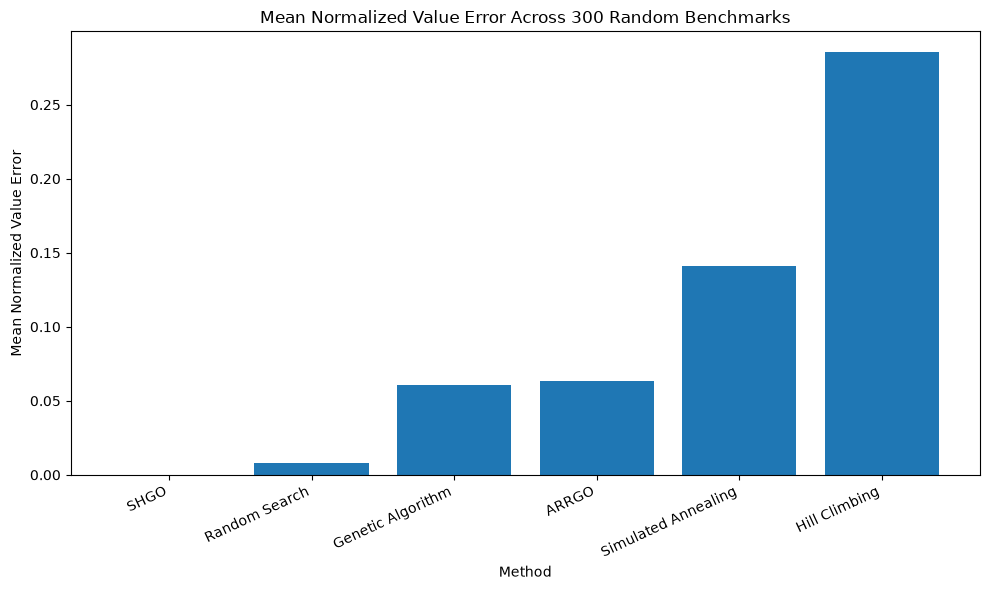

In [20]:
import matplotlib.pyplot as plt


plot_df = summary_df.sort_values(
    by="mean_normalized_value_error",
    ascending=True,
).copy()


plt.figure(figsize=(10, 6))

plt.bar(
    plot_df["method"],
    plot_df["mean_normalized_value_error"],
)

plt.xlabel("Method")
plt.ylabel("Mean Normalized Value Error")
plt.title(
    "Mean Normalized Value Error Across 300 Random Benchmarks"
)

plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

Success rate across 300 random benchmark functions:


,method,success_rate
0,SHGO,100.000000
1,Random Search,84.000000
2,Genetic Algorithm,67.333333
3,Simulated Annealing,65.333333
4,Hill Climbing,48.666667
5,ARRGO,46.666667


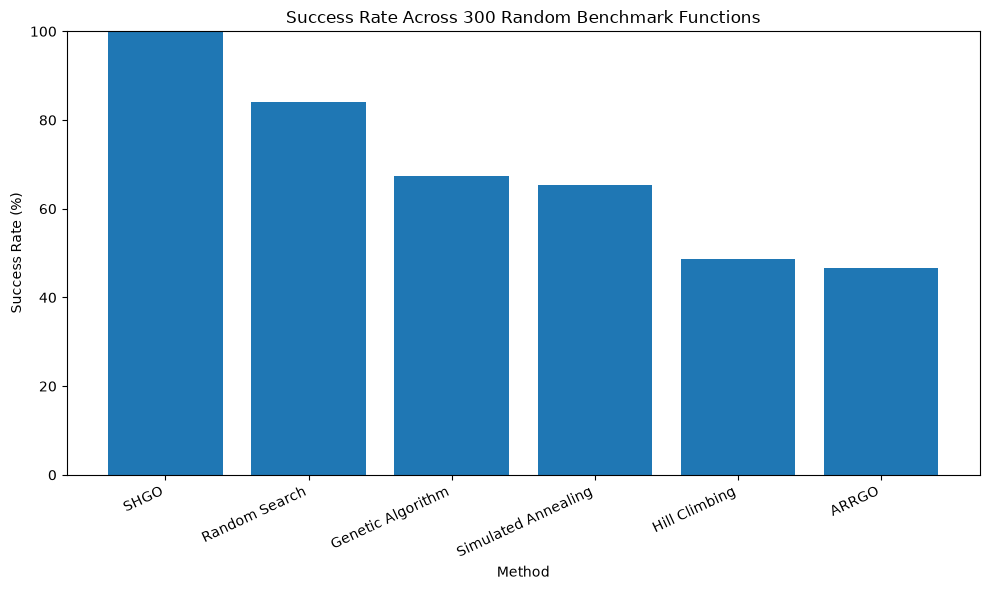

In [23]:
success_rate_df = (
    comparison_df
    .groupby("method")
    .agg(
        success_rate=("success", "mean"),
    )
    .reset_index()
)

success_rate_df["success_rate"] *= 100

success_rate_df = success_rate_df.sort_values(
    by="success_rate",
    ascending=False,
).reset_index(drop=True)


print("Success rate across 300 random benchmark functions:")
display(success_rate_df)


plt.figure(figsize=(10, 6))

plt.bar(
    success_rate_df["method"],
    success_rate_df["success_rate"],
)

plt.xlabel("Method")
plt.ylabel("Success Rate (%)")
plt.title(
    "Success Rate Across 300 Random Benchmark Functions"
)

plt.ylim(0, 100)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

Location error summary:


,method,mean_location_error,median_location_error
4,SHGO,2.942562e-08,8.026743e-09
3,Random Search,1.314522e-01,3.611873e-02
0,ARRGO,4.473167e-01,1.285225e-01
1,Genetic Algorithm,8.264773e-01,4.970862e-02
5,Simulated Annealing,1.766160e+00,2.217431e-02
2,Hill Climbing,2.671685e+00,1.928783e+00


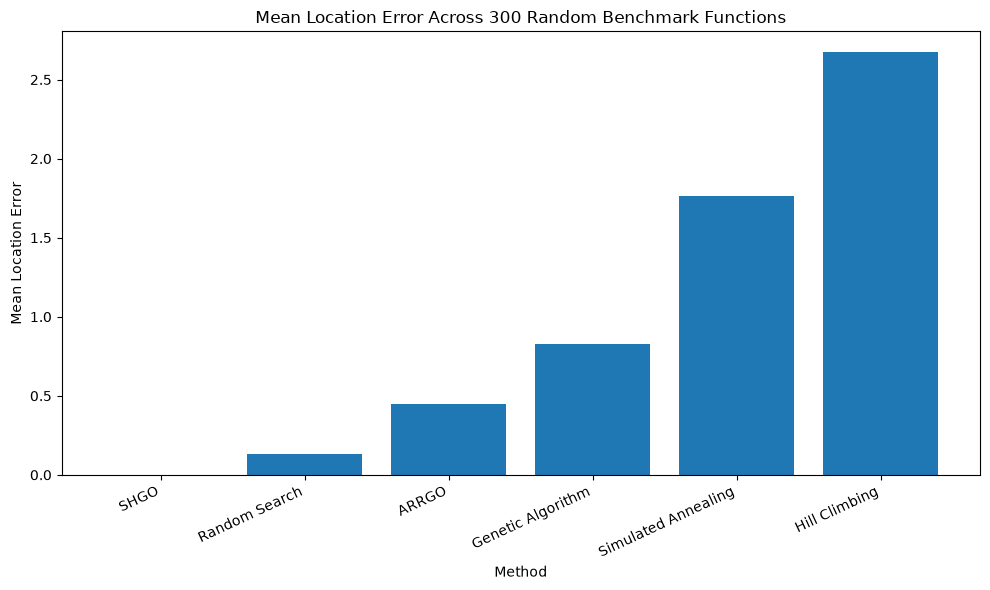

In [24]:
location_summary_df = (
    comparison_df
    .groupby("method")
    .agg(
        mean_location_error=("location_error", "mean"),
        median_location_error=("location_error", "median"),
    )
    .reset_index()
    .sort_values(
        by="mean_location_error",
        ascending=True,
    )
)


print("Location error summary:")
display(location_summary_df)


plt.figure(figsize=(10, 6))

plt.bar(
    location_summary_df["method"],
    location_summary_df["mean_location_error"],
)

plt.xlabel("Method")
plt.ylabel("Mean Location Error")
plt.title(
    "Mean Location Error Across 300 Random Benchmark Functions"
)

plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

In [26]:
convergence_records = []

for benchmark_id in comparison_df["benchmark_id"].unique():
    benchmark = random_benchmarks[benchmark_id - 1]

    reference = reference_by_id[benchmark_id]
    reference_value = float(reference["reference_value"])

    seed = RANDOM_BENCHMARK_SEED + benchmark_id

    for method_name in COMPARISON_METHODS:

        if method_name == "ARRGO":
            result = run_arrgo_comparison(
                objective=benchmark["objective"],
                lower_bound=benchmark["lower_bound"],
                upper_bound=benchmark["upper_bound"],
                max_evaluations=COMPARISON_MAX_EVALUATIONS,
            )

        elif method_name == "Random Search":
            result = run_random_search(
                objective=benchmark["objective"],
                lower_bound=benchmark["lower_bound"],
                upper_bound=benchmark["upper_bound"],
                max_evaluations=COMPARISON_MAX_EVALUATIONS,
                seed=seed,
            )

        elif method_name == "Hill Climbing":
            result = run_hill_climbing(
                objective=benchmark["objective"],
                lower_bound=benchmark["lower_bound"],
                upper_bound=benchmark["upper_bound"],
                max_evaluations=COMPARISON_MAX_EVALUATIONS,
                seed=seed,
            )

        elif method_name == "Genetic Algorithm":
            result = run_genetic_algorithm(
                objective=benchmark["objective"],
                lower_bound=benchmark["lower_bound"],
                upper_bound=benchmark["upper_bound"],
                max_evaluations=COMPARISON_MAX_EVALUATIONS,
                seed=seed,
            )

        elif method_name == "Simulated Annealing":
            result = run_simulated_annealing(
                objective=benchmark["objective"],
                lower_bound=benchmark["lower_bound"],
                upper_bound=benchmark["upper_bound"],
                max_evaluations=COMPARISON_MAX_EVALUATIONS,
                seed=seed,
            )

        elif method_name == "SHGO":
            result = run_shgo(
                objective=benchmark["objective"],
                lower_bound=benchmark["lower_bound"],
                upper_bound=benchmark["upper_bound"],
                max_evaluations=COMPARISON_MAX_EVALUATIONS,
                seed=seed,
            )

        history = result["history"]

        # ARRGO returns an EvaluationHistory object.
        if hasattr(history, "evaluations"):
            history_entries = history.evaluations
        else:
            history_entries = history

        best_so_far = -np.inf

        for history_entry in history_entries:

            if hasattr(history_entry, "value"):
                evaluation_number = history_entry.id
                current_value = float(history_entry.value)
            else:
                evaluation_number = history_entry["evaluation"]
                current_value = float(history_entry["value"])

            best_so_far = max(
                best_so_far,
                current_value,
            )

            normalized_error = (
                abs(reference_value - best_so_far)
                / max(abs(reference_value), 1e-12)
            )

            convergence_records.append(
                {
                    "benchmark_id": benchmark_id,
                    "method": method_name,
                    "evaluation": evaluation_number,
                    "normalized_value_error": normalized_error,
                }
            )


convergence_df = pd.DataFrame(convergence_records)


expected_convergence_rows = (
    RANDOM_BENCHMARK_COUNT
    * len(COMPARISON_METHODS)
    * COMPARISON_MAX_EVALUATIONS
)


assert len(convergence_df) == expected_convergence_rows

assert convergence_df[
    "normalized_value_error"
].ge(0).all()


print(
    f"Prepared {len(convergence_df)} convergence observations."
)

print(
    f"Expected observations: {expected_convergence_rows}"
)

convergence_df.head()

Prepared 180000 convergence observations.
Expected observations: 180000


,benchmark_id,method,evaluation,normalized_value_error
0,1,ARRGO,0,0.917936
1,1,ARRGO,1,0.656432
2,1,ARRGO,2,0.343252
3,1,ARRGO,3,0.343252
4,1,ARRGO,4,0.129331


Convergence summary:


,method,evaluation,mean_normalized_value_error,median_normalized_value_error
0,ARRGO,0,0.863578,0.829910
1,ARRGO,1,0.537606,0.460521
2,ARRGO,2,0.436039,0.394016
3,ARRGO,3,0.357612,0.276851
4,ARRGO,4,0.266986,0.219473
5,ARRGO,5,0.217787,0.155951
6,ARRGO,6,0.185892,0.118449
7,ARRGO,7,0.143093,0.076493
8,ARRGO,8,0.121927,0.054873
9,ARRGO,9,0.108722,0.043627


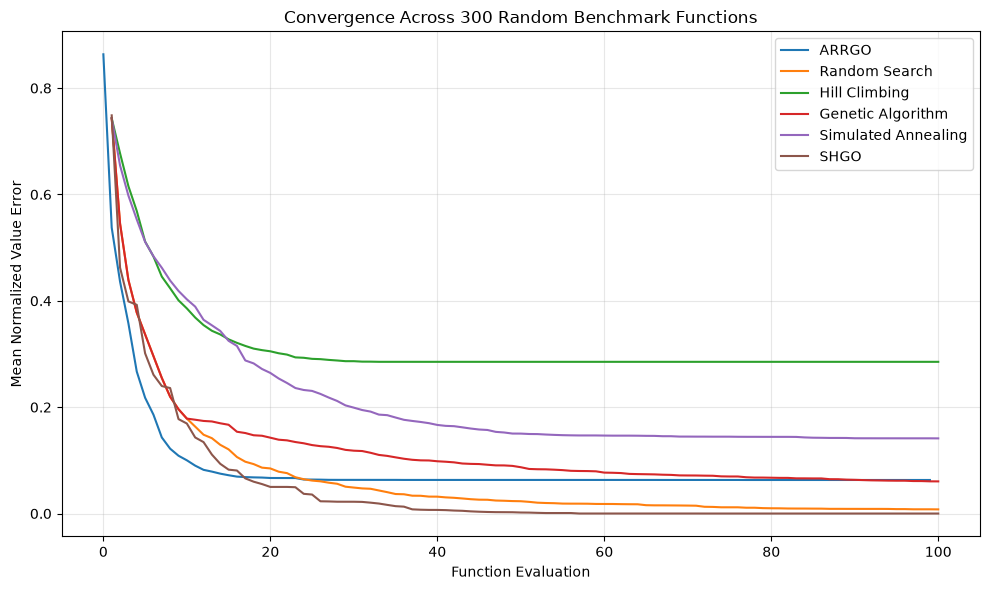

In [27]:
convergence_summary_df = (
    convergence_df
    .groupby(["method", "evaluation"])
    .agg(
        mean_normalized_value_error=(
            "normalized_value_error",
            "mean",
        ),
        median_normalized_value_error=(
            "normalized_value_error",
            "median",
        ),
    )
    .reset_index()
)


print("Convergence summary:")
display(convergence_summary_df.head(20))


plt.figure(figsize=(10, 6))

for method_name in COMPARISON_METHODS:
    method_data = convergence_summary_df[
        convergence_summary_df["method"] == method_name
    ]

    plt.plot(
        method_data["evaluation"],
        method_data["mean_normalized_value_error"],
        label=method_name,
    )


plt.xlabel("Function Evaluation")
plt.ylabel("Mean Normalized Value Error")
plt.title(
    "Convergence Across 300 Random Benchmark Functions"
)

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [28]:
convergence_checkpoints = (
    convergence_summary_df[
        convergence_summary_df["evaluation"].isin(
            [10, 20, 50, 100]
        )
    ]
    .pivot(
        index="method",
        columns="evaluation",
        values="mean_normalized_value_error",
    )
    .reset_index()
)

convergence_checkpoints.columns.name = None

convergence_checkpoints = convergence_checkpoints.rename(
    columns={
        10: "error_at_10",
        20: "error_at_20",
        50: "error_at_50",
        100: "error_at_100",
    }
)

print("Mean normalized value error at selected evaluation checkpoints:")
display(convergence_checkpoints)

Mean normalized value error at selected evaluation checkpoints:


,method,error_at_10,error_at_20,error_at_50,error_at_100
0,ARRGO,0.100098,0.066841,0.063174,NaN
1,Genetic Algorithm,0.178531,0.142624,0.087077,6.046060e-02
2,Hill Climbing,0.385711,0.305080,0.285282,2.852824e-01
3,Random Search,0.178531,0.084811,0.023142,7.805801e-03
4,SHGO,0.169250,0.050044,0.001924,6.175693e-15
5,Simulated Annealing,0.402795,0.264378,0.150314,1.413338e-01


In [29]:
# Normalize evaluation numbering so every method uses 1-based evaluations.
convergence_df.loc[
    convergence_df["method"] == "ARRGO",
    "evaluation",
] += 1


# Rebuild the convergence summary after fixing the evaluation index.
convergence_summary_df = (
    convergence_df
    .groupby(["method", "evaluation"])
    .agg(
        mean_normalized_value_error=(
            "normalized_value_error",
            "mean",
        ),
        median_normalized_value_error=(
            "normalized_value_error",
            "median",
        ),
    )
    .reset_index()
)


convergence_checkpoints = (
    convergence_summary_df[
        convergence_summary_df["evaluation"].isin(
            [10, 20, 50, 100]
        )
    ]
    .pivot(
        index="method",
        columns="evaluation",
        values="mean_normalized_value_error",
    )
    .reset_index()
)

convergence_checkpoints.columns.name = None

convergence_checkpoints = convergence_checkpoints.rename(
    columns={
        10: "error_at_10",
        20: "error_at_20",
        50: "error_at_50",
        100: "error_at_100",
    }
)

print(
    "Mean normalized value error at selected evaluation checkpoints:"
)

display(convergence_checkpoints)

Mean normalized value error at selected evaluation checkpoints:


,method,error_at_10,error_at_20,error_at_50,error_at_100
0,ARRGO,0.108722,0.067646,0.063174,6.308515e-02
1,Genetic Algorithm,0.178531,0.142624,0.087077,6.046060e-02
2,Hill Climbing,0.385711,0.305080,0.285282,2.852824e-01
3,Random Search,0.178531,0.084811,0.023142,7.805801e-03
4,SHGO,0.169250,0.050044,0.001924,6.175693e-15
5,Simulated Annealing,0.402795,0.264378,0.150314,1.413338e-01


Benchmark-wise final error winners:


,method,wins,win_rate
0,SHGO,300,100.000000
1,ARRGO,15,5.000000
2,Genetic Algorithm,3,1.000000
3,Hill Climbing,3,1.000000
4,Simulated Annealing,1,0.333333


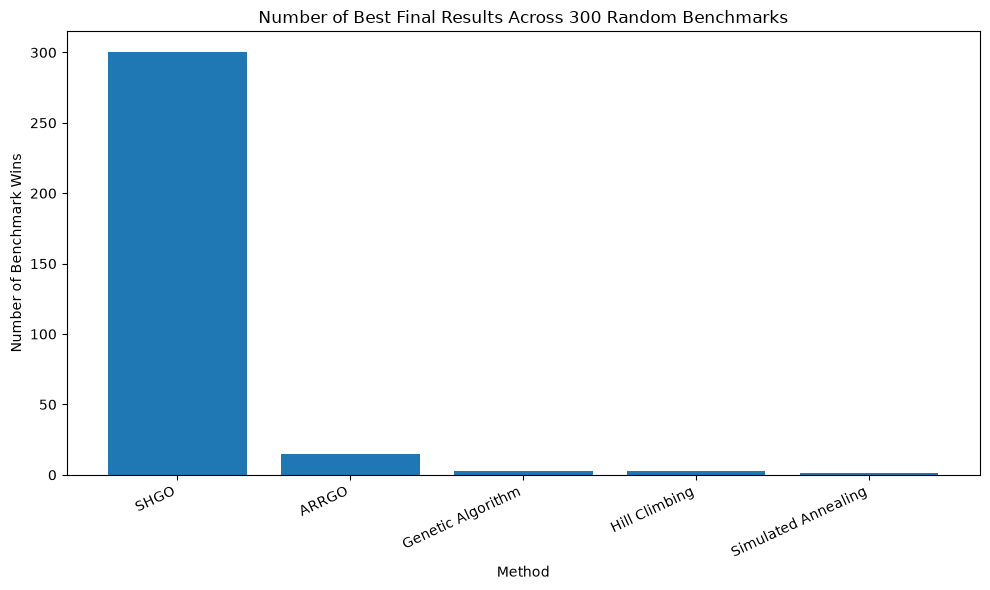

In [30]:
final_error_by_benchmark = (
    comparison_df
    .groupby(
        ["benchmark_id", "method"],
        as_index=False,
    )
    .agg(
        final_normalized_value_error=(
            "normalized_value_error",
            "first",
        )
    )
)

# Use the final error from each benchmark-method pair.
final_error_by_benchmark = (
    comparison_df[
        [
            "benchmark_id",
            "method",
            "normalized_value_error",
        ]
    ]
    .copy()
)


winner_rows = []

for benchmark_id, benchmark_group in (
    final_error_by_benchmark
    .groupby("benchmark_id")
):
    best_error = benchmark_group[
        "normalized_value_error"
    ].min()

    winners = benchmark_group[
        np.isclose(
            benchmark_group["normalized_value_error"],
            best_error,
            rtol=1e-10,
            atol=1e-12,
        )
    ]

    for _, winner in winners.iterrows():
        winner_rows.append(
            {
                "benchmark_id": benchmark_id,
                "method": winner["method"],
            }
        )


winner_df = pd.DataFrame(winner_rows)

win_counts_df = (
    winner_df
    .groupby("method")
    .size()
    .reset_index(name="wins")
)

win_counts_df["win_rate"] = (
    win_counts_df["wins"]
    / RANDOM_BENCHMARK_COUNT
    * 100
)

win_counts_df = win_counts_df.sort_values(
    by="wins",
    ascending=False,
).reset_index(drop=True)


print("Benchmark-wise final error winners:")
display(win_counts_df)


plt.figure(figsize=(10, 6))

plt.bar(
    win_counts_df["method"],
    win_counts_df["wins"],
)

plt.xlabel("Method")
plt.ylabel("Number of Benchmark Wins")
plt.title(
    "Number of Best Final Results Across 300 Random Benchmarks"
)

plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

In [31]:
arrgo_results = comparison_df[
    comparison_df["method"] == "ARRGO"
].copy()

arrgo_results["component_count"] = arrgo_results[
    "benchmark_id"
].apply(
    lambda benchmark_id:
    random_benchmarks[benchmark_id - 1]["parameters"]["component_count"]
)

arrgo_results["mean_width"] = arrgo_results[
    "benchmark_id"
].apply(
    lambda benchmark_id:
    float(
        np.mean(
            random_benchmarks[
                benchmark_id - 1
            ]["parameters"]["widths"]
        )
    )
)

arrgo_results["max_width"] = arrgo_results[
    "benchmark_id"
].apply(
    lambda benchmark_id:
    float(
        np.max(
            random_benchmarks[
                benchmark_id - 1
            ]["parameters"]["widths"]
        )
    )
)

arrgo_results["min_width"] = arrgo_results[
    "benchmark_id"
].apply(
    lambda benchmark_id:
    float(
        np.min(
            random_benchmarks[
                benchmark_id - 1
            ]["parameters"]["widths"]
        )
    )
)

arrgo_results["is_success"] = (
    arrgo_results["normalized_value_error"]
    <= COMPARISON_SUCCESS_TOLERANCE
)


arrgo_success_profile = (
    arrgo_results
    .groupby("component_count")
    .agg(
        benchmark_count=("benchmark_id", "count"),
        successful_benchmarks=("is_success", "sum"),
        mean_normalized_error=(
            "normalized_value_error",
            "mean",
        ),
    )
    .reset_index()
)

arrgo_success_profile["success_rate"] = (
    arrgo_success_profile["successful_benchmarks"]
    / arrgo_success_profile["benchmark_count"]
    * 100
)

arrgo_success_profile = arrgo_success_profile.sort_values(
    by="component_count"
).reset_index(drop=True)


print("ARRGO success profile by landscape complexity:")
display(arrgo_success_profile)

ARRGO success profile by landscape complexity:


,component_count,benchmark_count,successful_benchmarks,mean_normalized_error,success_rate
0,2,65,31,0.083574,47.692308
1,3,60,31,0.047289,51.666667
2,4,50,25,0.063592,50.000000
3,5,66,30,0.069330,45.454545
4,6,59,23,0.049162,38.983051


## 26. Final Comparative Conclusion

The comparative experiment evaluated ARRGO against Random Search, Hill Climbing, Genetic Algorithm, Simulated Annealing, and SHGO on 300 deterministic randomly generated one-dimensional benchmark functions.

All methods were evaluated under the same objective functions, domain bounds, and maximum budget of 100 explicit objective evaluations per benchmark. The comparison used final objective quality, normalized value error, location error, success rate, and convergence behavior.

The results show that SHGO achieved the strongest overall performance under the experimental configuration used in this study. It obtained an approximately zero mean normalized value error and achieved the lowest final error on all 300 benchmark functions.

Random Search also performed strongly, particularly in terms of final mean and median normalized value error. Genetic Algorithm provided competitive performance, while Simulated Annealing and Hill Climbing showed larger variability and higher average error under the selected configuration.

ARRGO achieved competitive but not dominant performance. Its mean normalized value error was approximately 6.31%, compared with approximately 6.05% for Genetic Algorithm and 0.78% for Random Search. ARRGO also showed a clear reduction in error during the early evaluation stages, followed by a comparatively stable error level later in the budget. ARRGO achieved a 46.7% success rate under the defined 1% normalized-error threshold and obtained the best final result on 15 of the 300 benchmark functions.

These results do not establish universal superiority or inferiority of any optimization method. The benchmark functions were generated from a single synthetic family of smooth Gaussian-mixture landscapes, the reference solutions were numerical approximations rather than analytical global-optimum proofs, and stochastic methods were evaluated using one fixed seed per benchmark. Method-specific parameters were also not exhaustively optimized.

The comparative experiment therefore provides empirical evidence about the behavior of ARRGO under a controlled experimental setting rather than a universal ranking of optimization algorithms.

The main empirical observation concerning ARRGO is that its region-based adaptive refinement mechanism can achieve competitive optimization quality while exhibiting a distinct convergence profile from the baseline methods. The results also identify clear opportunities for future improvement in candidate selection, refinement allocation, and parameter adaptation.

### Scientific Conclusion

The experimental evidence supports the following bounded conclusion:

> Under the benchmark generator, evaluation budget, reference-solution procedure, and algorithm configurations used in this study, ARRGO demonstrates competitive global-optimization behavior but does not outperform the strongest baseline, SHGO, on the selected synthetic benchmark family.

This result is consistent with the research scope of ARRGO. The contribution of the framework is not claimed to be universal dominance over existing optimization algorithms. Instead, ARRGO is proposed as a deterministic, region-based, information-driven framework whose mathematical structure supports adaptive refinement and whose finite-dimensional generalization was established theoretically in Notebook 07.

The experimental comparison therefore complements, rather than replaces, the theoretical development and validation presented in the previous notebooks.